In [ ]:
import pandas as pd

# Official, guaranteed stable URL from Databricks public data repository
stable_url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"

# Load the data into your notebook
df = pd.read_csv(stable_url)

# Print a success message and show the table shape
print(f"Success! Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Success! Loaded 541909 rows and 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# 1. Check for missing values in each column
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check basic stats of numerical columns to look for weird anomalies
print("\n--- Summary Statistics ---")
df[['Quantity', 'UnitPrice']].describe()


--- Missing Values ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- Summary Statistics ---


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [ ]:
# 1. Drop missing Customer IDs
df_clean = df.dropna(subset=['CustomerID'])

# 2. Keep only positive quantities and unit prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 3. Create a 'TotalSales' column
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 4. Check the new dataset size and look at the new summary stats
print(f"Original dataset rows: {df.shape[0]}")
print(f"Cleaned dataset rows: {df_clean.shape[0]}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}\n")

print("--- Cleaned Summary Statistics ---")
print(df_clean[['Quantity', 'UnitPrice', 'TotalSales']].describe())


Original dataset rows: 541909
Cleaned dataset rows: 397884
Rows removed: 144025

--- Cleaned Summary Statistics ---
            Quantity      UnitPrice     TotalSales
count  397884.000000  397884.000000  397884.000000
mean       12.988238       3.116488      22.397000
std       179.331775      22.097877     309.071041
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.680000
50%         6.000000       1.950000      11.800000
75%        12.000000       3.750000      19.800000
max     80995.000000    8142.750000  168469.600000


In [ ]:
# 1. Find the Top 5 Best-Selling Products by Revenue
top_products = df_clean.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(5)

# 2. Find the Top 5 Countries by Revenue
top_countries = df_clean.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(5)

print("🏆 --- TOP 5 PRODUCTS BY REVENUE --- 🏆")
print(top_products.apply(lambda x: f"${x:,.2f}")) # Formats numbers cleanly as currency

print("\n🌍 --- TOP 5 COUNTRIES BY REVENUE --- 🌍")
print(top_countries.apply(lambda x: f"${x:,.2f}"))


🏆 --- TOP 5 PRODUCTS BY REVENUE --- 🏆
Description
PAPER CRAFT , LITTLE BIRDIE           $168,469.60
REGENCY CAKESTAND 3 TIER              $142,592.95
WHITE HANGING HEART T-LIGHT HOLDER    $100,448.15
JUMBO BAG RED RETROSPOT                $85,220.78
MEDIUM CERAMIC TOP STORAGE JAR         $81,416.73
Name: TotalSales, dtype: object

🌍 --- TOP 5 COUNTRIES BY REVENUE --- 🌍
Country
United Kingdom    $7,308,391.55
Netherlands         $285,446.34
EIRE                $265,545.90
Germany             $228,867.14
France              $209,024.05
Name: TotalSales, dtype: object


1. Fetching data from the cloud...
2. Cleaning missing data and removing negative sales...
3. Extracting the top 5 products...
4. Generating your analytics chart...


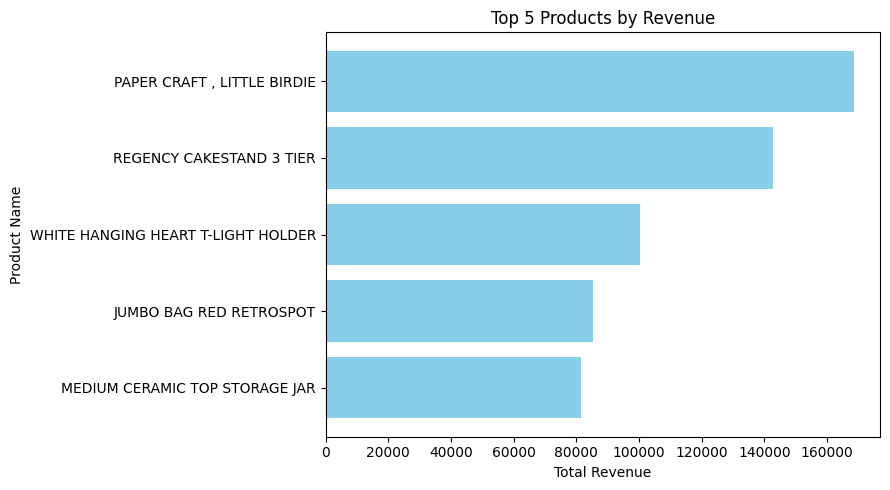

Success! Everything is completed.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("1. Fetching data from the cloud...")
stable_url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"
df = pd.read_csv(stable_url)

print("2. Cleaning missing data and removing negative sales...")
# Drop missing Customer IDs and keep valid quantities/prices
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Create the TotalSales revenue column
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("3. Extracting the top 5 products...")
top_products_fresh = df_clean.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(5)
product_names = list(top_products_fresh.index)
product_revenue = list(top_products_fresh.values)

print("4. Generating your analytics chart...")
plt.figure(figsize=(9, 5))
plt.barh(product_names, product_revenue, color='skyblue')
plt.title("Top 5 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.tight_layout()

# Render the final chart directly on your screen
plt.show()
print("Success! Everything is completed.")


In [ ]:
import pandas as pd

# 1. Standardize dates
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2. Run calculations
rfm = pd.DataFrame()
rfm['Recency'] = df_clean.groupby('CustomerID')['InvoiceDate'].max().apply(lambda x: (snapshot_date - x).days)
rfm['Frequency'] = df_clean.groupby('CustomerID')['InvoiceNo'].count()
rfm['Monetary'] = df_clean.groupby('CustomerID')['TotalSales'].sum()

# 3. Simple bucket sorting using plain numbers
rfm['Status'] = pd.cut(rfm['Recency'], bins=[0, 180, 10000], labels=['Active', 'At_Risk'])

# 4. Ultra-safe basic printing (No symbols, emojis, or long strings)
print("RESULTS:")
print(rfm['Status'].value_counts())


RESULTS:
Status
Active     3478
At_Risk     860
Name: count, dtype: int64
